Read the xml file

In [1]:
import xml.etree.ElementTree as ET

def parse_xml(filename):
    tree = ET.parse(filename)
    root = tree.getroot()
    data_from_xml = []

    for testcase in root.iter("testcase"):
        props = {}
        for prop in testcase.find("properties").iter("property"):
            name = prop.attrib["name"]
            value = prop.attrib["value"]
            props[name] = value

        entry = {
                 "circuit_class": props["circuit_class"],
                "num_qubits": int(props["num_qubits"]),
                "num_blocks": int(props["num_blocks"]),
                "time_sec": float(props["time_sec"]),
                "peak_memory_mb": float(props["peak_memory_bytes"]) / (1024**2),
                "num_threads": int(props["num_threads"])
            }
        data_from_xml.append(entry)
        
    return data_from_xml


In [2]:
data_from_xml = [] 
for i in range(1, 21):
    filename = f"../data/perf_thread_tests/perf_results_test_{i}_threads.xml"
    data = parse_xml(filename)
    data_from_xml.extend(data)

In [3]:
def filter_data(raw_data, filters):
    filtered = [
        d for d in raw_data if all(d[k] == v for k, v in filters.items())
    ]
    return filtered

In [4]:
len(filter_data(data_from_xml, {"num_blocks": 5}))

720

In [5]:
data_from_xml[0]

{'circuit_class': 'QuspinQuantumSensingCircuit',
 'num_qubits': 5,
 'num_blocks': 5,
 'time_sec': 0.7160197279881686,
 'peak_memory_mb': 16.07305335998535,
 'num_threads': 1}

Plot the results for analyzing number of threads

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_data_grouped_by_threads(ax, raw_data, x_key, y_key, title, x_label, y_label):
    grouped_by_threads = {}
    for entry in raw_data:
        threads = int(entry['num_threads'])  # Ensure threads are ints for sorting
        if threads not in grouped_by_threads: 
            grouped_by_threads[threads] = []
        grouped_by_threads[threads].append(entry)
        
    # Sort thread counts to map to the colormap correctly
    sorted_threads = sorted(grouped_by_threads.keys())
    # Setup colormap (e.g., 'viridis', 'plasma', 'coolwarm')
    cmap = cm.viridis
    norm = mcolors.Normalize(vmin=min(sorted_threads), vmax=max(sorted_threads))
    for threads in sorted_threads:
        entries_per_thread = grouped_by_threads[threads]
        # Sort x_values to ensure the line is drawn sequentially
        # Assuming entries_per_thread is a list of dicts. We sort the list based on x_key.
        entries_per_thread.sort(key=lambda x: x[x_key])
        x_values = [e[x_key] for e in entries_per_thread]
        y_values = [e[y_key] for e in entries_per_thread]
        # Get color for this thread count
        color = cmap(norm(threads))
        ax.plot(x_values, y_values, marker='o', color=color, label=f"{threads} threads")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True)
  
    # Add Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) # Only needed for older matplotlib versions
    # Attach the colorbar to the axes
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Number of Threads')
    
    # Remove the standard legend as it is now redundant
    # ax.legend()
    
def plot_memory_and_time(data_to_plot, x_key, x_label):
    classes = sorted(list(set(d['circuit_class'] for d in data_to_plot)))
    
    fig, axes = plt.subplots(nrows=len(classes), ncols=2, figsize=(15, 5 * len(classes)))
    
    for i, cclass in enumerate(classes):
        filtered_by_class = filter_data(data_to_plot, {"circuit_class": cclass})
        
        # Time plot
        ax_time = axes[i][0]
        plot_data_grouped_by_threads(
            ax_time, filtered_by_class, 
            x_key=x_key, y_key="time_sec",
            title=f"{cclass} - Time vs Num Qubits",
            x_label=x_label,
            y_label="Time (s)"
        )
        
        # Memory plot
        ax_mem = axes[i][1]
        plot_data_grouped_by_threads(
            ax_mem, filtered_by_class, 
            x_key=x_key, y_key="peak_memory_mb",
            title=f"{cclass} - Memory vs Num Qubits",
            x_label=x_label,
            y_label="Memory (Megabytes)"
        )
    
    plt.tight_layout()
    plt.show()

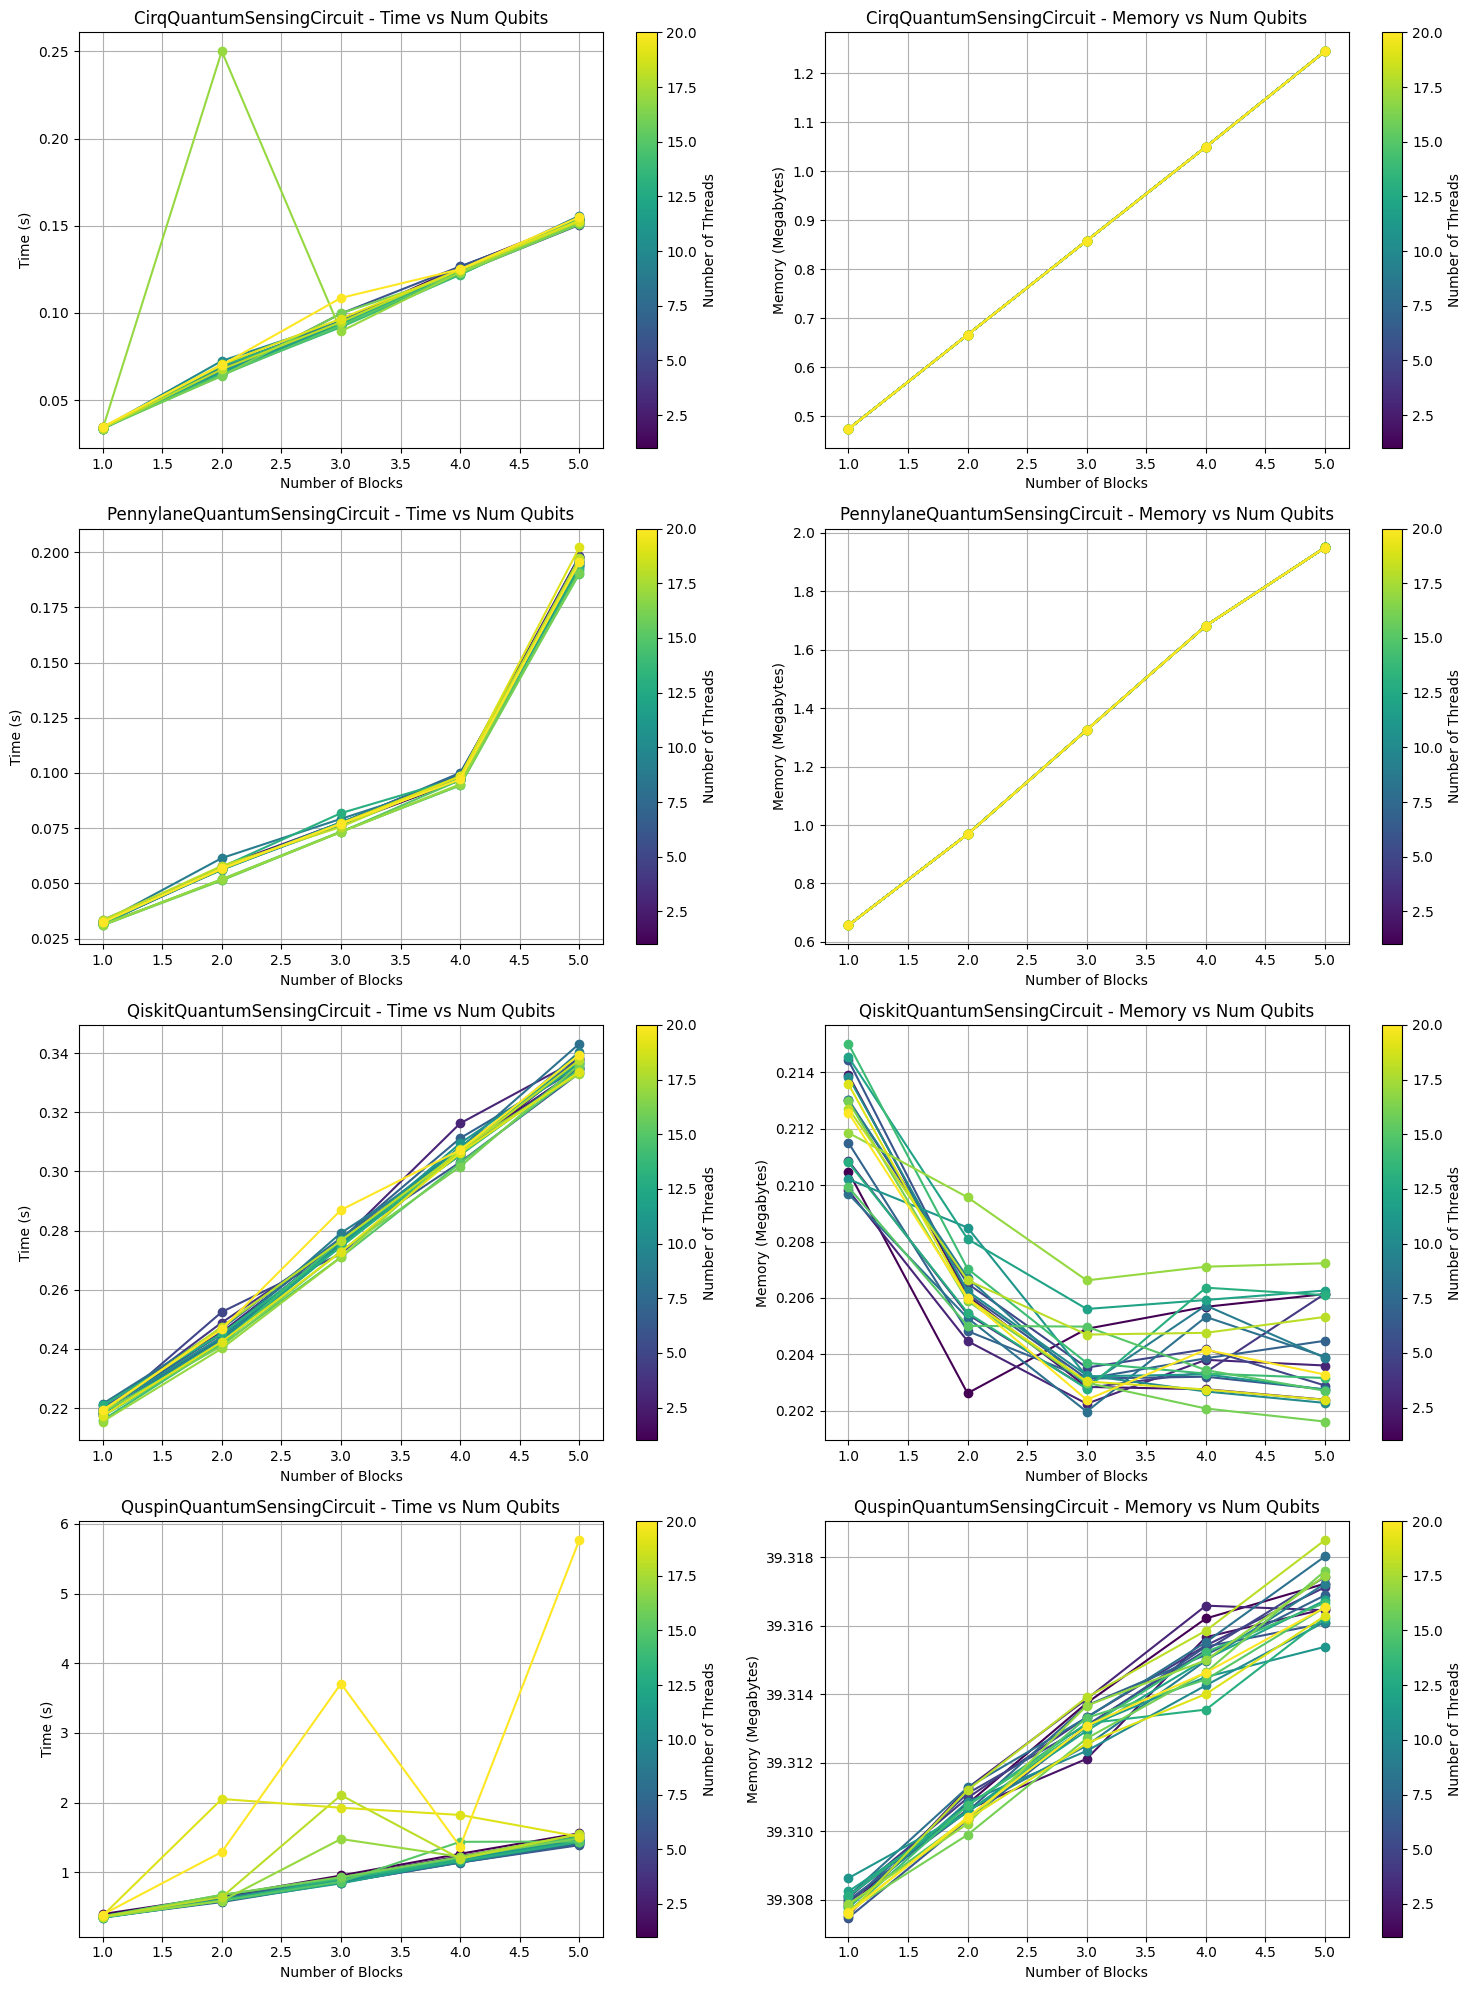

In [10]:
data_for_13_qubits = filter_data(data_from_xml, {"num_qubits": 13})
plot_memory_and_time(data_for_13_qubits, x_key="num_blocks", x_label="Number of Blocks")

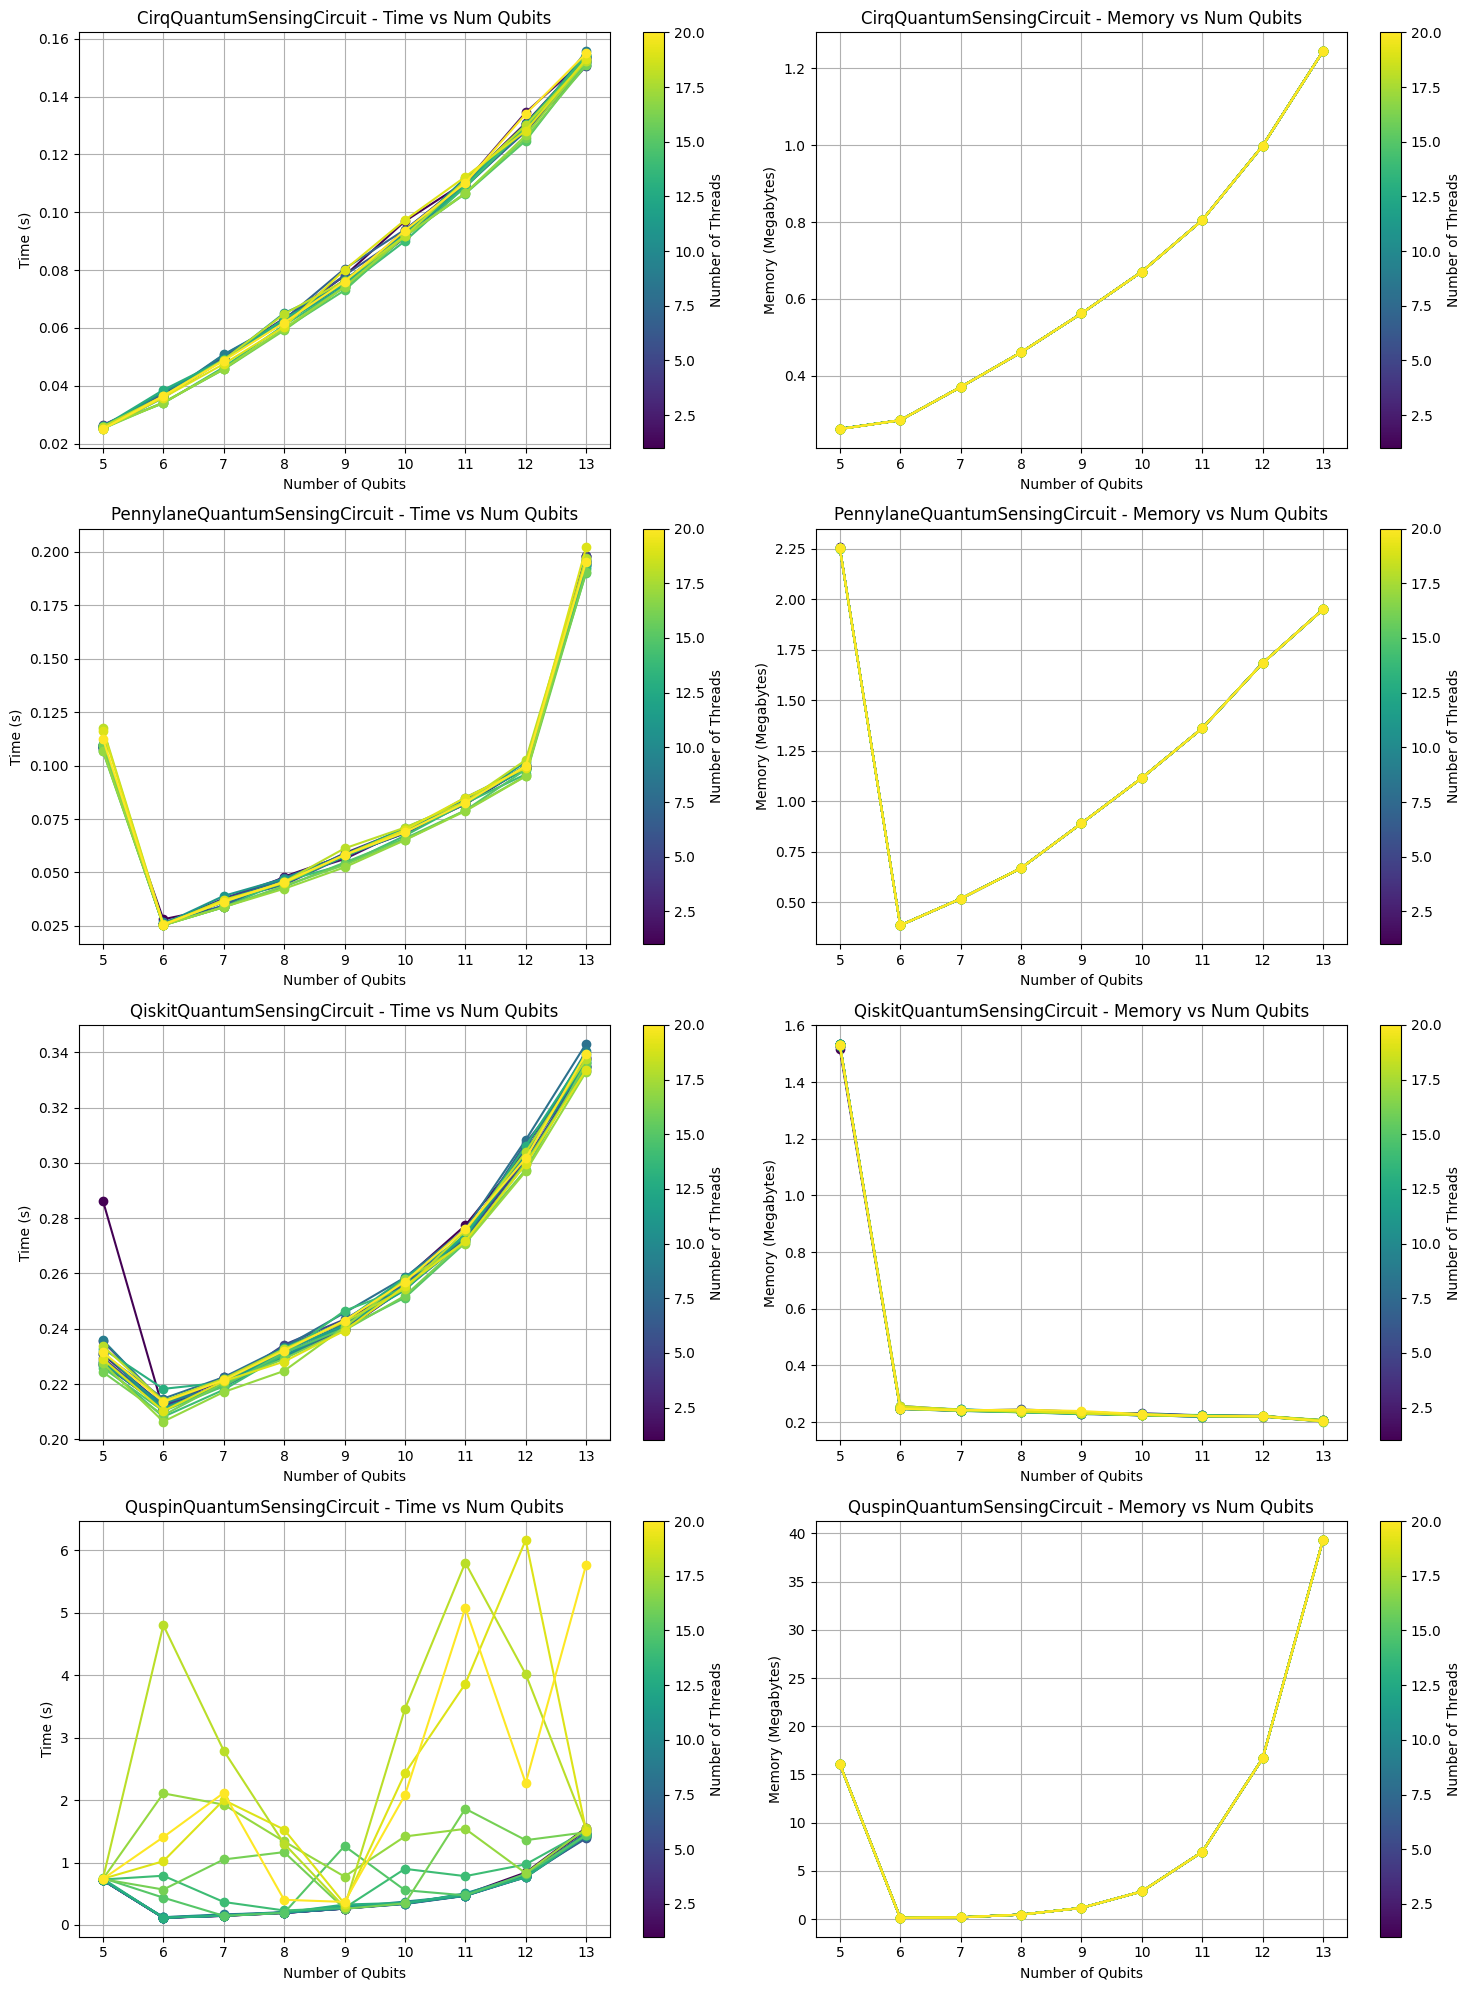

In [11]:
data_for_5_blocks = filter_data(data_from_xml, {"num_blocks": 5})
plot_memory_and_time(data_for_5_blocks, x_key="num_qubits", x_label="Number of Qubits")

It seems, that increasing number of threads to run a circuit has no significant improvement, infact in case of QuSpin it makes things worse.